# Feature extraction and Price Prediction for Mobile Phones
## Organisation: NextHikes IT Solutions
## Role: Data Science Intern
## Name: Diwanshi Soni
#### Objective: The objective of this project is to build a machine learning model that can predict the price of a mobile phone based on its features such as RAM, storage, battery capacity, camera specifications, and processor. The project also aims to identify the most influential features affecting mobile phone prices through feature extraction and analysis. This helps understand how different specifications contribute to pricing. The insights can support organizations in improving pricing strategies and product planning.

In [1]:
#import libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Dataset Loading
## The dataset is first loaded into the working environment (such as Python using the Pandas library) to begin the analysis. This step allows us to view the structure of the data, including rows, columns, and data types. After loading, initial functions like head(), info(), and describe() are used to understand the dataset before further preprocessing and analysis.

In [3]:
df = pd.read_csv(r"C:\Users\DELL\OneDrive\Desktop\Project_4\Processed_Flipdata - Processed_Flipdata.csv")

In [4]:
df.head()

,Unnamed: 0,Model,Colour,Memory,RAM,Battery_,Rear Camera,Front Camera,AI Lens,Mobile Height,Processor_,Prize
0,0,Infinix SMART 7,Night Black,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
1,1,Infinix SMART 7,Azure Blue,64,4,6000,13MP,5MP,1,16.76,Unisoc Spreadtrum SC9863A1,"7,299"
2,2,MOTOROLA G32,Mineral Gray,128,8,5000,50MP,16MP,0,16.64,Qualcomm Snapdragon 680,"11,999"
3,3,POCO C50,Royal Blue,32,2,5000,8MP,5MP,0,16.56,Mediatek Helio A22,"5,649"
4,4,Infinix HOT 30i,Marigold,128,8,5000,50MP,5MP,1,16.76,G37,"8,999"


# Data Exploration
## Data exploration involves analyzing the dataset to understand its structure, variables, and basic statistics. In this step, we examine the number of rows and columns, data types, and summary statistics using tools like head(), info(), and describe() in Pandas. This helps identify patterns, missing values, and potential issues in the data before further preprocessing and modeling.

In [5]:
df.shape

(541, 12)

In [6]:
df.dtypes

Unnamed: 0         int64
Model             object
Colour            object
Memory             int64
RAM                int64
Battery_           int64
Rear Camera       object
Front Camera      object
AI Lens            int64
Mobile Height    float64
Processor_        object
Prize             object
dtype: object

In [7]:
df.describe()

,Unnamed: 0,Memory,RAM,Battery_,AI Lens,Mobile Height
count,541.000000,541.000000,541.000000,541.000000,541.000000,541.000000
mean,289.711645,110.550832,5.397412,4871.587800,0.062847,16.431201
std,182.359185,60.600694,1.984923,780.148862,0.242911,2.523553
min,0.000000,16.000000,2.000000,800.000000,0.000000,4.500000
25%,135.000000,64.000000,4.000000,5000.000000,0.000000,16.510000
50%,273.000000,128.000000,6.000000,5000.000000,0.000000,16.710000
75%,434.000000,128.000000,8.000000,5000.000000,0.000000,16.940000
max,642.000000,256.000000,8.000000,7000.000000,1.000000,41.940000


In [8]:
df.isnull().sum()

Unnamed: 0       0
Model            0
Colour           0
Memory           0
RAM              0
Battery_         0
Rear Camera      0
Front Camera     0
AI Lens          0
Mobile Height    0
Processor_       0
Prize            0
dtype: int64

# Data Preprocessing
## Data preprocessing involves cleaning and preparing the dataset before building the model. In this step, missing values, outliers, and inconsistencies in the data are handled to improve data quality. 

In [9]:
df.ffill(inplace=True)

# Encoding Categorical Values 

In [10]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

## Label encoding is a technique used to convert categorical text data into numerical values so that machine learning models can process it. Each unique category is assigned a unique integer value (e.g., Black = 0, Blue = 1, Red = 2). In Python, this method is commonly implemented using the LabelEncoder class from scikit-learn.

# Exploratory Data Analysis
## Exploratory Data Analysis is the process of analyzing and visualizing the dataset to understand patterns, relationships, and trends among variables. It involves using summary statistics and visualizations such as histograms, box plots, and correlation matrices. Libraries like Pandas and Matplotlib are commonly used for performing EDA.

## Price Distribution Graph

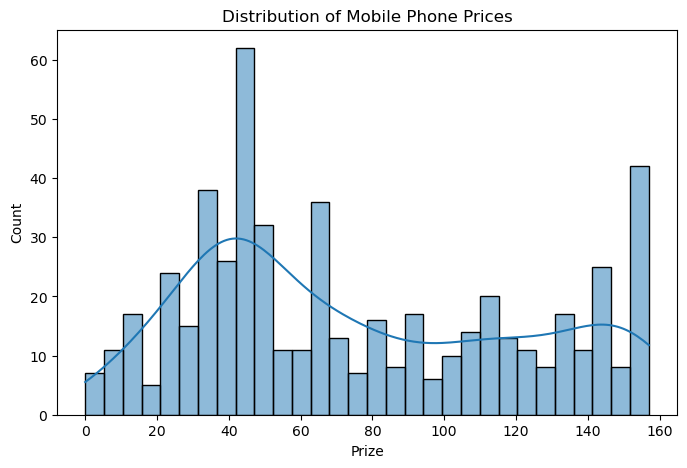

In [11]:
plt.figure(figsize=(8,5))
sns.histplot(df["Prize"], bins=30, kde=True)
plt.title("Distribution of Mobile Phone Prices")
plt.show()

## The price distribution graph shows how mobile phone prices are spread across the dataset. It helps identify whether prices are normally distributed or skewed. This insight helps understand pricing trends in the dataset.

## RAM Vs Price Graph

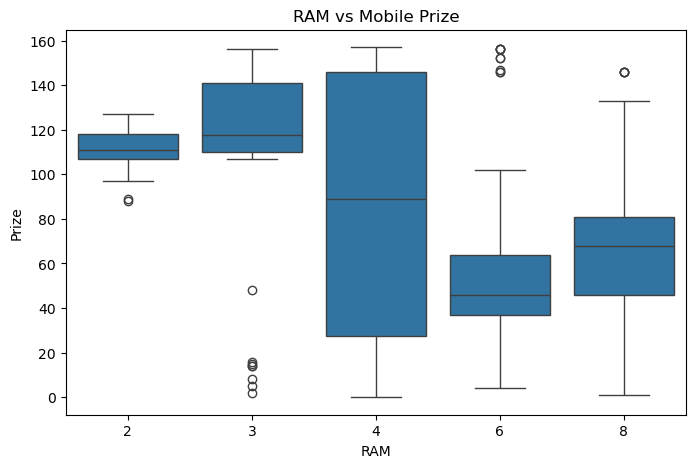

In [12]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df["RAM"], y=df["Prize"])
plt.title("RAM vs Mobile Prize")
plt.show()

## Storage Vs Price

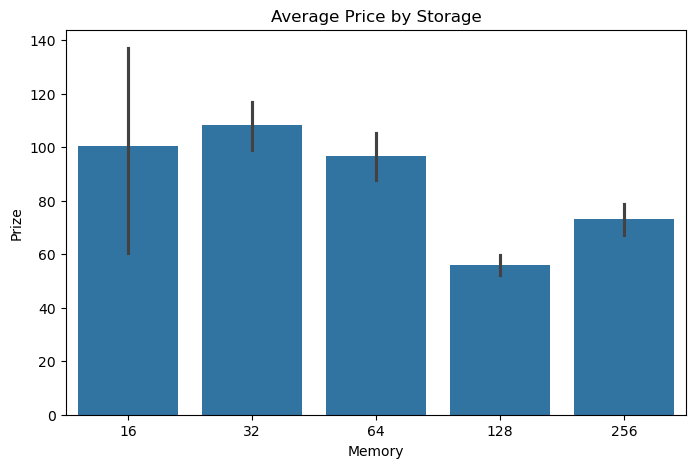

In [13]:
plt.figure(figsize=(8,5))
sns.barplot(x=df["Memory"], y=df["Prize"])
plt.title("Average Price by Storage")
plt.show()

## Battery Capacity Vs Price

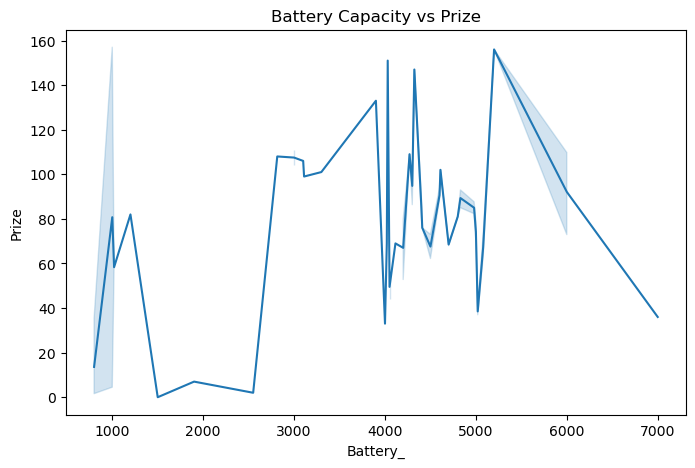

In [14]:
plt.figure(figsize=(8,5))
sns.lineplot(x=df["Battery_"], y=df["Prize"])
plt.title("Battery Capacity vs Prize")
plt.show()

## Processor Vs Price

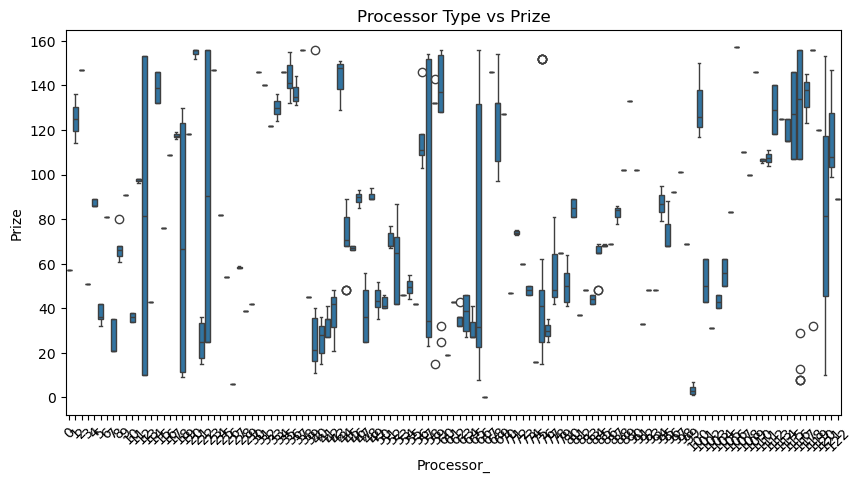

In [15]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df["Processor_"], y=df["Prize"])
plt.xticks(rotation=45)
plt.title("Processor Type vs Prize")
plt.show()

# Correlation Heatmap

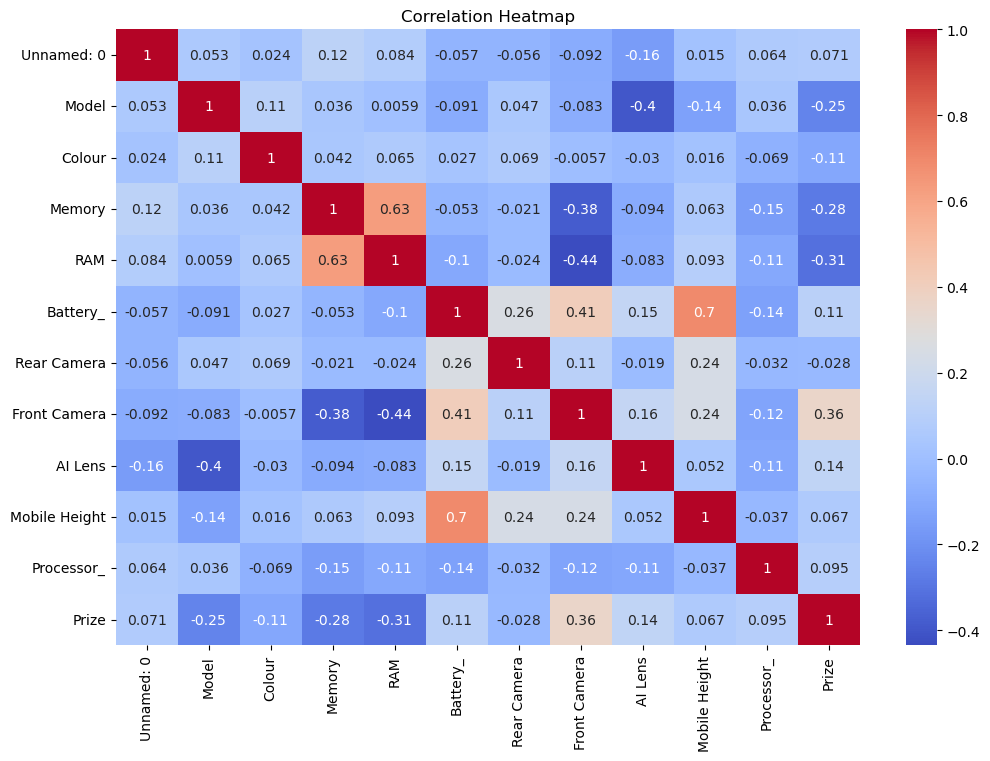

In [16]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

## A correlation heatmap is a visualization technique used to display the strength and direction of relationships between different variables in a dataset. It helps identify which features are strongly related to the target variable, such as price. 

# Feature Extraction

In [17]:
price_correlation = df.corr()["Prize"].sort_values(ascending=False)
price_correlation

Prize            1.000000
Front Camera     0.359096
AI Lens          0.141326
Battery_         0.111657
Processor_       0.095286
Unnamed: 0       0.070675
Mobile Height    0.066867
Rear Camera     -0.027760
Colour          -0.112165
Model           -0.245361
Memory          -0.282521
RAM             -0.312492
Name: Prize, dtype: float64

## Feature extraction is the process of identifying and selecting the most important variables that influence the target variable, such as mobile phone price. It helps reduce irrelevant or less useful features and improves model performance.

# Train-Test Split

In [18]:
X = df.drop("Prize", axis=1)
y = df["Prize"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train–test split is the process of dividing the dataset into two parts: a training set and a testing set. The training data is used to train the machine learning model, while the testing data is used to evaluate its performance on unseen data.

<h1>Model Building</h1>

# Linear Regression

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

## Linear regression is a machine learning algorithm used to predict a continuous value by modeling the relationship between independent variables and a dependent variable. It fits a straight line to the data to estimate the target value, such as predicting mobile phone price from its features

# Decision Tree regression

In [20]:
dt_model = DecisionTreeRegressor()
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)

## Decision Tree Regression is a machine learning algorithm that predicts continuous values by splitting the dataset into smaller subsets based on feature conditions. It creates a tree-like structure where each node represents a decision based on a feature.

# Random Forest Regression

In [21]:
rf_model = RandomForestRegressor()
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

## Random Forest Regression is an ensemble machine learning method that builds multiple decision trees and combines their predictions to improve accuracy. It reduces overfitting by averaging the results from many trees trained on different subsets of the data.

# Model Evaluation

In [22]:
def evaluate_model(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    return mae, rmse, r2

## Model evaluation is the process of measuring how well a machine learning model performs on unseen data. It helps determine the accuracy and reliability of the model’s predictions using metrics such as Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

# Model Comparison Table

In [23]:
results = pd.DataFrame({
"Model": ["Linear Regression", "Decision Tree", "Random Forest"],

"MAE": [
evaluate_model(y_test, lr_pred)[0],
evaluate_model(y_test, dt_pred)[0],
evaluate_model(y_test, rf_pred)[0]
],

"RMSE": [
evaluate_model(y_test, lr_pred)[1],
evaluate_model(y_test, dt_pred)[1],
evaluate_model(y_test, rf_pred)[1]
],

"R2 Score": [
evaluate_model(y_test, lr_pred)[2],
evaluate_model(y_test, dt_pred)[2],
evaluate_model(y_test, rf_pred)[2]
]

})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,33.480630,39.995894,0.293588
1,Decision Tree,8.477064,22.949086,0.767428
2,Random Forest,12.209725,21.935653,0.787515


## The model comparison table helps evaluate which algorithm performs best. By comparing MAE, RMSE, and R² scores, we can determine the most accurate model for predicting mobile phone prices.

# Feature Importance Chart

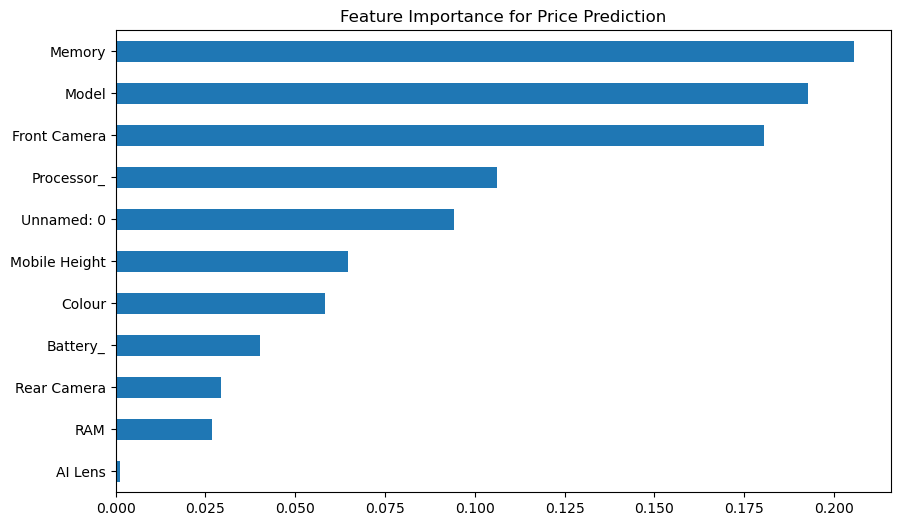

In [24]:
importance = rf_model.feature_importances_
feature_importance = pd.Series(importance, index=X.columns)
feature_importance.sort_values().plot(kind="barh", figsize=(10,6))
plt.title("Feature Importance for Price Prediction")
plt.show()

## The feature importance chart highlights which features contribute the most to the model’s predictions. This helps identify the key factors influencing mobile phone prices.

# Key Insights
## The analysis shows that certain features significantly influence mobile phone prices. RAM and processor type appear to be strong predictors of price. Battery capacity and internal memory also contribute to higher pricing. These features are commonly associated with high-performance smartphones.

# Business Recommendations
## Based on the analysis, companies should focus on improving RAM, processor performance, and battery capacity when designing premium smartphones. Highlighting these features in marketing strategies can help justify higher pricing and attract customers seeking high performance devices.